In [1]:
import os
import sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# from matplotlib.colors import LinearSegmentedColormap
# from matplotlib.collections import LineCollection
# from scipy.ndimage import gaussian_filter1d
#from matplotlib import gridspec
from matplotlib.ticker import MultipleLocator
from matplotlib.lines import Line2D

# Add parent directory to sys.path
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
    
sns.set_theme(style="white")
work_path = "M:/1confiProj/"
os.chdir(work_path)
from scripts.plot_function import *
from scripts.experiments import DataHandler
from scripts.evaluators import ModelEvaluator
plot_path = 'M:\\1confiProj\\Analysis\\output\\'

device is : cpu


In [2]:
# load beh data
dh = DataHandler(cluster=False)
df_beh = dh.get_allsub_beh_data()
sub_lst = [2, 3, 5, 6, 11, 15, 20, 25]

## 1.Localization raw data

### Sub-level

In [3]:
def add_counts(df, ax, xloc, yloc,color):
    counts = df.groupby('AudLoc').size()
    for audloc, count in counts.items():
        ax.annotate(f'{count}', xy=(audloc+xloc, yloc), xytext=(0, 5), textcoords='offset points', ha='center', fontsize=12, color=color)
def add_avg_line(df, ax,color, resp_var='RespLoc'):
    avg_response = df.groupby('AudLoc')[resp_var].mean().reset_index()
    ax.plot(avg_response['AudLoc'], avg_response[resp_var], color=color, linewidth=1,alpha=0.7)

In [4]:
def plot_raw_rep_sub(df, sub_id, rel, ax, visloc, palette, resp_var='RespLoc', modality='A', legend=True, offset = 1, avg_line=False, n_case = True):
    df_plot = df[(df['Modality'] == modality)&(df.VisRelLabel==rel)&(df.sub_id == sub_id)]

    # Congruent condition
    df_same = df_plot[df_plot.AudLoc == df_plot.VisLoc]
    ax.plot(df_same['AudLoc'], df_same[resp_var], 'o', color='red', markersize=2, alpha=0.7, label='Congruent')

    # Congruent condition
    df_vis = df_plot[df_plot.VisLoc == visloc]
    ax.plot(df_vis['AudLoc'] + offset, df_vis[resp_var], 'o', color=palette[visloc], markersize=2, alpha=0.7, label=f'Visual Stimulus Location = {visloc}')
    
    if avg_line:
        add_avg_line(df=df_same, ax=ax, color = 'red', resp_var=resp_var)
        add_avg_line(df=df_vis, ax=ax, color = palette[visloc], resp_var=resp_var)
    if n_case:
        add_counts(df=df_same, ax=ax, xloc=0, yloc=15.5, color='red')
        add_counts(df=df_vis, ax=ax, xloc=0, yloc=14, color=palette[visloc])
    
    if resp_var=='RespLoc':
        # add the reference lines
        ax.plot([-10, 10], [-10, 10], '--', color='red', linewidth=1, alpha=0.6, zorder=0)
        ax.hlines(y=visloc, xmin=-10, xmax=10, color=palette[visloc], linestyle='--', linewidth=1)

    if visloc!=0:
        df_vism = df_plot[df_plot.VisLoc == -visloc]
        ax.plot(df_vism['AudLoc'] - offset, df_vism[resp_var], 'o', color=palette[-visloc], markersize=2, alpha=0.7, label=f'Visual Stimulus Location = -{visloc}')
        if resp_var=='RespLoc':
            ax.hlines(y=-visloc, xmin=-10, xmax=10, color=palette[-visloc], linestyle='--', linewidth=1)

        if avg_line:
            add_avg_line(df=df_vism, ax=ax, color=palette[-visloc], resp_var=resp_var)
        if n_case:
            add_counts(df=df_vism, ax=ax, xloc=0, yloc=-16, color=palette[-visloc])

    if legend:
        ax.legend(frameon=False, ncol=2,fontsize=fontsize-2, loc='lower center', bbox_to_anchor=(0.9, -0.55))

    clean_axs(ax)

    ax.set_xlabel('Sound Location ($^\\circ$)', fontsize=fontsize)
    ## Autoscale first
    ax.xaxis.set_major_locator(MultipleLocator(5))
    if resp_var=='RespLoc':
        ax.set_aspect('equal', adjustable='box')
        ax.yaxis.set_major_locator(MultipleLocator(5))
        
    #ax.set_ylabel('Response Location', fontsize=12)

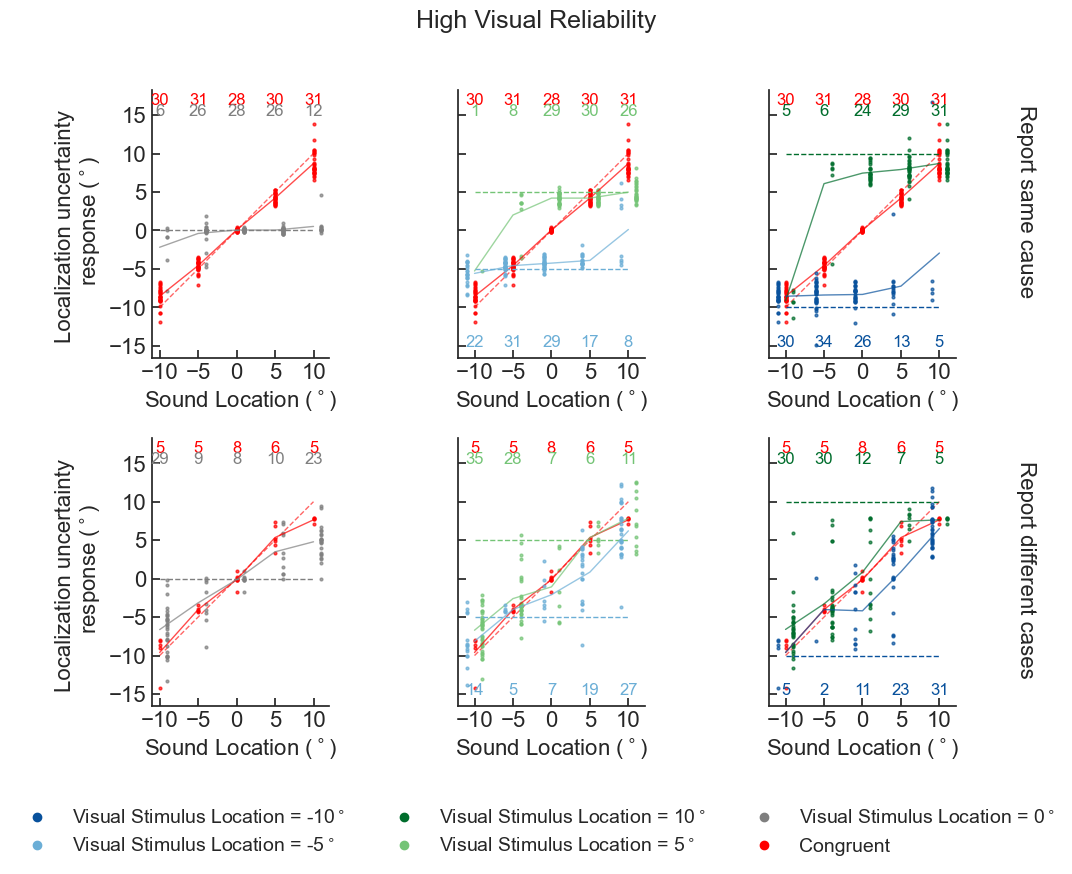

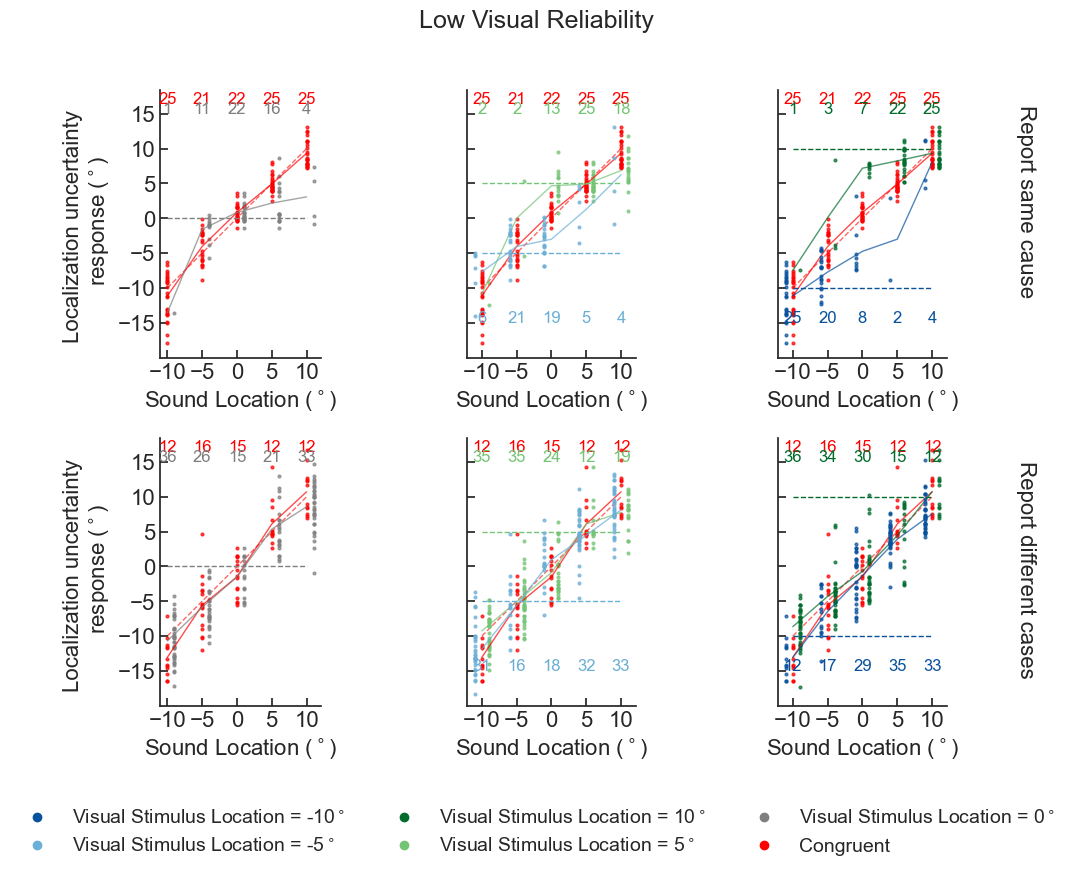

In [ ]:
sub_id= 11
# palette_vloc = {
#     -10: "#08519c",  # dark blue
#     -5:  "#6baed6",  # light blue
#      0:  "#7f7f7f",  # gray
#      5:  "#74c476",  # light green
#     10: "#006d2c",   # dark green
# }
for vrel in ['High', 'Low']:
    fig, axs = plt.subplots(
        nrows=2, ncols=3,
        figsize=(12, 8),
        sharey=True,
        #constrained_layout=True
        gridspec_kw={'wspace': 0.01, 'hspace': 0.3}
    )
    for row, sources in enumerate([1, 2]):
        for col, visloc in enumerate([0, 5, 10]):
            plot_raw_rep_sub(
                df=df_beh.loc[df_beh.Sources==sources], 
                sub_id=sub_id, 
                rel=vrel, 
                ax=axs[row,col], 
                visloc=visloc, 
                legend=False, 
                avg_line=True,
                palette=palette_vloc
            )

    legend_elements = [
        Line2D(
            [0], [0],
            linestyle='None',
            marker='o',
            markersize=6,
            markerfacecolor=palette_vloc[vloc],
            markeredgecolor=palette_vloc[vloc],
            label=f"Visual Stimulus Location = {vloc}$^\\circ$"
        )
        for vloc in [-10, -5, 10, 5, 0]
    ]
    axs[1,0].set_ylabel('Localization uncertainty \n response ($^\\circ$)', fontsize=fontsize)
    axs[0,0].set_ylabel('Localization uncertainty \n response ($^\\circ$)', fontsize=fontsize)
    legend_elements.append(
        Line2D(
            [0], [0],
            linestyle='None',
            marker='o',
            markersize=6,
            markerfacecolor='red',
            markeredgecolor='red',
            label="Congruent",
        )
    )

    fig.legend(
        handles=legend_elements,
        frameon=False,
        ncol=3,
        fontsize=fontsize-2,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.1)
    )
    
    fig.suptitle(f'{vrel} Visual Reliability', fontsize=fontsize+2)
    fig.text(
        0.9, 0.74, 'Report same cause',
        va='center', ha='left',
        fontsize=fontsize, rotation=270
    )

    fig.text(
        0.9, 0.28, 'Report different cases',
        va='center', ha='left',
        fontsize=fontsize, rotation=270
    )

    plt.savefig(os.path.join(plot_path, 'sub_select',  f'sub_{sub_id}_raw_rep_plot_vis_{vrel}.png'), bbox_inches='tight', dpi=300)

### All sub (mean)

In [ ]:
def scale_marker_size(n, global_min, global_max,
                      power=2, smin=50, smax=300):
    # first power then scale to make the trial counts difference more visible
    n = np.power(n, power)
    gmin_pw = np.power(global_min, power)
    gmax_pw = np.power(global_max, power)
    return (
        smin +
        (n - gmin_pw) /
        (gmax_pw - gmin_pw) *
        (smax - smin)
    )

def plot_raw_rep_all(df, rel, ax, visloc, palette,
                     resp_var='RespLoc',
                     modality='A',
                     legend=True,
                     scale = True):

    df_plot = df[(df['Modality'] == modality) &
                 (df['VisRelLabel'] == rel)]

    # ------------------------------------------------------------
    # Helper function
    # ------------------------------------------------------------
    def plot_condition(df_cond, color, label):

        # Mean, SEM and total number of trials - two steps averaging
        summary_sub = (
            df_cond
            .groupby(["AudLoc", "sub_id"])
            .agg(
                mean=(resp_var, "mean"),
                #sem=(resp_var, "sem"),
                n=(resp_var, "size")
            )
            .reset_index()
            #.sort_values("AudLoc")
        )
        summary = (
            summary_sub
            .groupby(["AudLoc"])
            .agg(
                mean=('mean', "mean"),
                sem=('mean', "sem"),
                n=('n', "sum")
            )
            .reset_index()
            .sort_values("AudLoc")
        )

        if scale:
            summary["marker_size"] = scale_marker_size(summary["n"], global_min, global_max,
                      power=2, smin=50, smax=300)

        else:
            summary["marker_size"] = summary["n"]

        ax.scatter(
            summary["AudLoc"],
            summary["mean"],
            s=summary["marker_size"],
            color=color,
            # edgecolors="black",
            # linewidth=0.5,
            zorder=3,
            alpha=0.7,
        )
        ax.errorbar(
            summary["AudLoc"],
            summary["mean"],
            yerr=summary["sem"],
            color=color,
            linewidth=2,
            capsize=2,
            label=label,
            zorder=2,
            #alpha=0.7,
            marker='o',
            markersize=5,
        )


    # ------------------------------------------------------------
    # Congruent condition
    # ------------------------------------------------------------
    plot_condition(
        df_plot[df_plot.AudLoc == df_plot.VisLoc],
        color="red",
        label="Congruent"
    )
    if resp_var=='RespLoc':
        ax.plot(
            [-10, 10],
            [-10, 10],
            "--",
            color="red",
            linewidth=1,
            alpha=0.6
        )

    # ------------------------------------------------------------
    # Fixed positive visual location
    # ------------------------------------------------------------
    plot_condition(
        df_plot[df_plot.VisLoc == visloc],
        color=palette[visloc],
        label=f"Visual Stimulus Location = {visloc}"
    )
    if resp_var=='RespLoc':
        ax.hlines(
            y=visloc,
            xmin=-10,
            xmax=10,
            color=palette[visloc],
            linestyle="--",
            linewidth=1
        )

    # ------------------------------------------------------------
    # Fixed negative visual location
    # ------------------------------------------------------------
    if visloc != 0:

        plot_condition(
            df_plot[df_plot.VisLoc == -visloc],
            color=palette[-visloc],
            label=f"Visual Stimulus Location = {-visloc}"
        )
        if resp_var=='RespLoc':
            ax.hlines(
                y=-visloc,
                xmin=-10,
                xmax=10,
                color=palette[-visloc],
                linestyle="--",
                linewidth=1
            )

    # ------------------------------------------------------------
    # Formatting
    # ------------------------------------------------------------
    if legend:
        ax.legend(
            frameon=False,
            ncol=2,
            fontsize=fontsize-2,
            loc="lower center",
            bbox_to_anchor=(0.9, -0.5)
        )

    clean_axs(ax)
    if resp_var=='RespLoc':
        ax.set_aspect('equal', adjustable='box')
        ax.yaxis.set_major_locator(MultipleLocator(5))
    ax.xaxis.set_major_locator(MultipleLocator(5))
    ax.set_xlabel('Sound Location ($^\\circ$)', fontsize=fontsize)
    #ax.set_ylabel('Auditory Response Location ($^\\circ$)', fontsize=fontsize)

In [3]:
df_plot = df_beh[(df_beh['Modality'] == 'A')]
all_summary_sub = (
    df_plot
    .groupby(["AudLoc", "VisLoc", "sub_id", 'VisRelLabel', 'Sources'])
    .agg(n=('RespLoc', "size"))
    .reset_index()
)

all_summary = (
    all_summary_sub
    .groupby(["AudLoc", "VisLoc", 'VisRelLabel', 'Sources'])
    .agg(n=("n", "sum"))
    .reset_index()
)

# power = 1.5
# global_n = np.power(all_summary["n"], power)

global_min = all_summary["n"].min()
global_max = all_summary["n"].max()
global_min, global_max

(np.int64(14), np.int64(282))

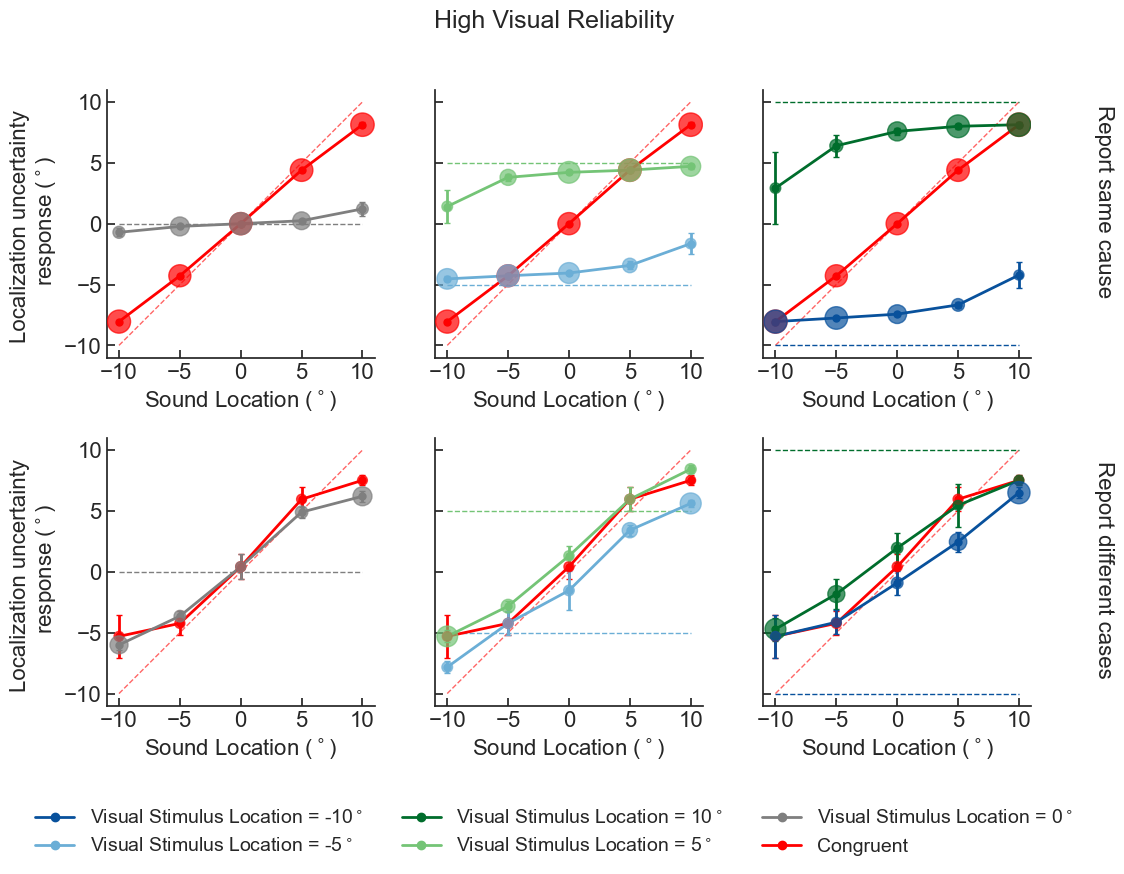

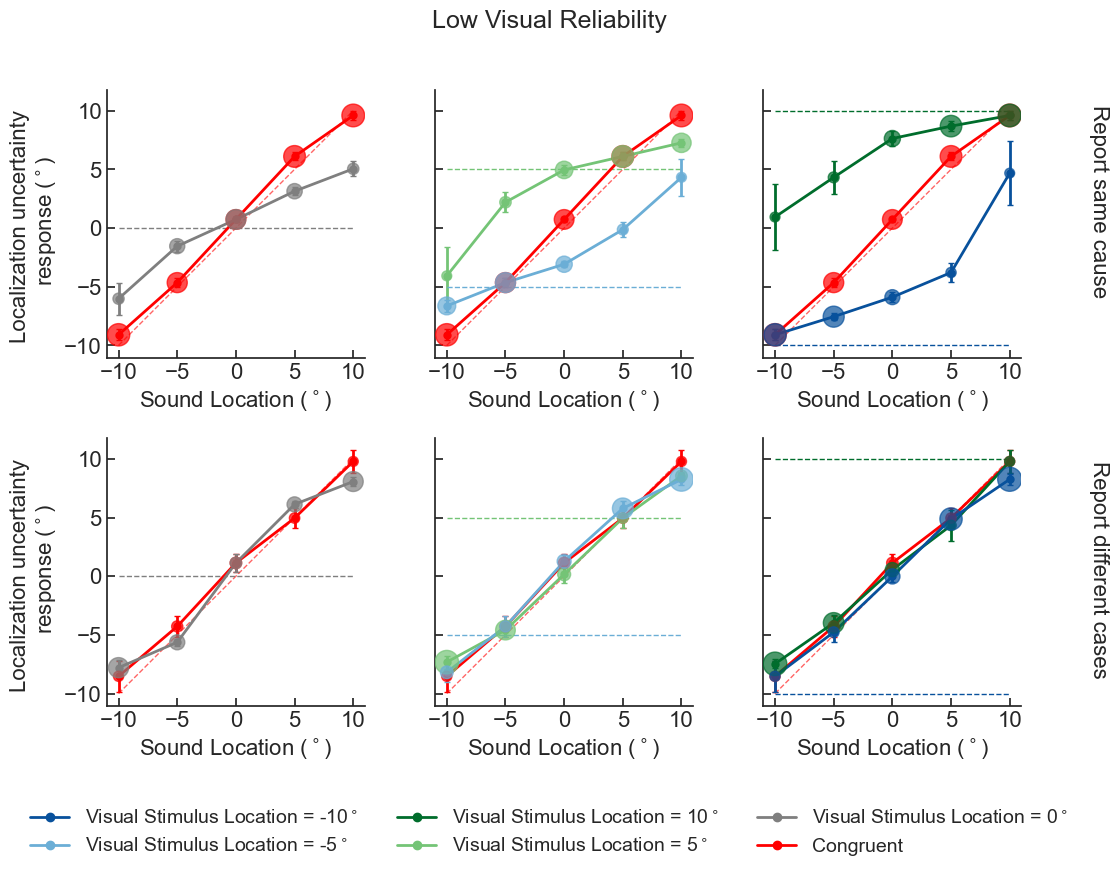

In [4]:
# palette_vloc = {
#     -10: "#08519c",  # dark blue
#     -5:  "#6baed6",  # light blue
#      0:  "#7f7f7f",  # gray
#      5:  "#74c476",  # light green
#     10: "#006d2c",   # dark green
# }

for vrel in ['High', 'Low']:
    fig, axs = plt.subplots(
        nrows=2, ncols=3,
        figsize=(12, 8),
        sharey=True,
        gridspec_kw={'wspace':0.2, 'hspace': 0.3}
    )

    for row, sources in enumerate([1, 2]):
        for col, visloc in enumerate([0, 5, 10]):
            plot_raw_rep_all(
                df=df_beh.loc[df_beh.Sources == sources],
                rel=vrel,
                ax=axs[row, col],
                visloc=visloc,
                #resp_var='CISize',
                legend=False,
                palette=palette_vloc,
                global_min=global_min,
                global_max = global_max,
                power=2
            )


    legend_elements = [
        Line2D(
            [0], [0],
            color=palette_vloc[vloc],
            lw=2,
            marker='o',
            markersize=6,
            markerfacecolor=palette_vloc[vloc],
            markeredgecolor=palette_vloc[vloc],
            label=f"Visual Stimulus Location = {vloc}$^\\circ$"
        )
        for vloc in [-10, -5, 10, 5, 0]
    ]
    legend_elements.append(
                       Line2D(
                        [0], [0],
                        color='red',
                        lw=2,
                        marker='o',
                        markersize=6,
                        markerfacecolor='red',
                        markeredgecolor='red',
                        label="Congruent",
                    ))
    fig.legend(
        handles=legend_elements,
        title='',
        frameon=False,
        ncol=3,
        fontsize=fontsize-2,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.1)
    )
    
    fig.suptitle(f'{vrel} Visual Reliability', fontsize=fontsize+2)

    axs[1,0].set_ylabel('Localization uncertainty \n response ($^\\circ$)', fontsize=fontsize)
    axs[0,0].set_ylabel('Localization uncertainty \n response ($^\\circ$)', fontsize=fontsize)

    fig.text(
        0.95, 0.74, 'Report same cause',
        va='center', ha='left',
        fontsize=fontsize, rotation=270
    )

    fig.text(
        0.95, 0.28, 'Report different cases',
        va='center', ha='left',
        fontsize=fontsize, rotation=270
    )
    #fig.supylabel('Auditory Response Location', fontsize=fontsize)
    plt.savefig(os.path.join(plot_path,'Raw_loc', f'Allsub_raw_re_plot_vis_{vrel}.png'), bbox_inches='tight', dpi=300)

## 2.Localization uncertainty estimate

### by spatial disparity

In [27]:
def plot_CI_size_by_disp(df, m_id=None, ax=None, Modality='A', legend=False, scale=False):
    
    if m_id is not None:
        #model simulation data
        df = df.loc[(df.m_id == m_id) & (df.Modality == Modality)].copy()
    else:
        #beh data
        df = df.loc[df.Modality == Modality].copy()
    #df_plot = df.groupby(['sub_id', 'VisRelLabel', 'abs_delta_VA']).CISize.mean().reset_index()

    # ------------------------------------------------------------
    # Helper function
    # ------------------------------------------------------------
    def plot_condition(df, vrel):
        df_cond = df.loc[df.VisRelLabel==vrel]
        # Mean, SEM and total number of trials - two steps averaging
        summary_sub = (
            df_cond
            .groupby(['abs_delta_VA', "sub_id"])
            .agg(
                mean=('CISize', "mean"),
                n=('CISize', "size")
            )
            .reset_index()
        )
        summary = (
            summary_sub
            .groupby(["abs_delta_VA"])
            .agg(
                mean=('mean', "mean"),
                sem=('mean', "sem"),
                n=('n', "sum")
            )
            .reset_index()
            .sort_values("abs_delta_VA")
        )

        if scale:
            #summary["marker_size"] = scale_marker_size(summary["n"], global_min, global_max )
            pass
        else:
            summary["marker_size"] = summary["n"]

        ax.scatter(
            summary["abs_delta_VA"],
            summary["mean"],
            s=summary["marker_size"],
            color=palette_beh[vrel],
            # edgecolors="black",
            # linewidth=0.5,
            zorder=3,
            alpha=0.7,
        )
        ax.errorbar(
            summary["abs_delta_VA"],
            summary["mean"],
            yerr=summary["sem"],
            color=palette_beh[vrel],
            linewidth=2,
            capsize=2,
            label=f'{vrel} visual reliability',
            zorder=2,
            #alpha=0.7,
            marker='o',
            markersize=5,
        )

    plot_condition(df, 'High')
    plot_condition(df, 'Low')
    if legend:
        ax.legend(
            frameon=False,
            ncol=2,
            fontsize=fontsize-2,
            loc='lower center',
            bbox_to_anchor=(0.4, -0.4),
        )

    clean_axs(ax)
    #ax.set_xlabel('Absolute spatial disparity (V - A, visual angle \u00B0)', fontsize=fontsize)
    #ax.set_ylabel('Localization uncertainty response', fontsize=fontsize)
    
 

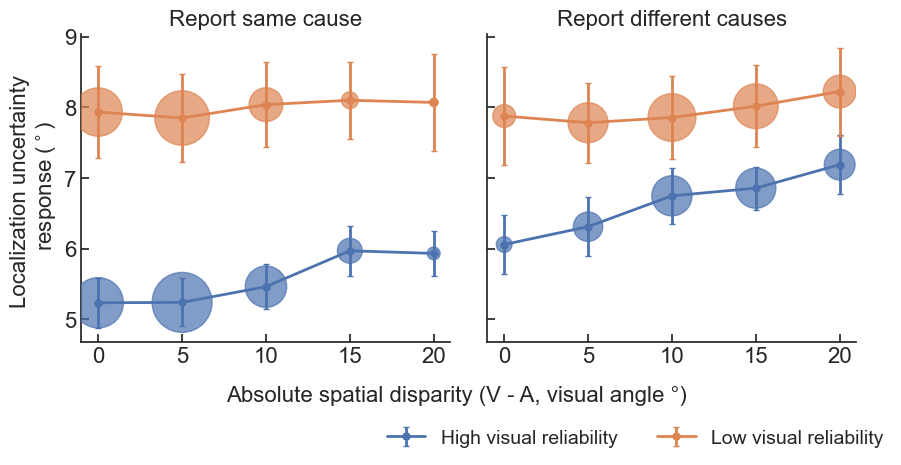

In [5]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 4), sharey=True, gridspec_kw={'wspace': 0.1})
plot_CI_size_by_disp(df=df_beh.loc[df_beh.Sources==1], ax=axs[0])
plot_CI_size_by_disp(df=df_beh.loc[df_beh.Sources==2], ax=axs[1], legend=True)
axs[0].set_title('Report same cause', fontsize=fontsize)
axs[1].set_title('Report different causes', fontsize=fontsize)
fig.supxlabel('Absolute spatial disparity (V - A, visual angle \u00B0)', fontsize=fontsize, y=-0.05)
axs[0].set_ylabel('Localization uncertainty \n response ($^\\circ$)', fontsize=fontsize)
plt.savefig(os.path.join(plot_path, 'conf_inter', 'Allsub_ci_by_causal_disp.png'), bbox_inches='tight', dpi=300)

In [61]:
def plot_CI_size_by_condition(df, m_id=None, axs=None, Modality='A', loc_var = 'AudLoc'):
    
    if m_id is not None:
        #model simulation data
        df = df.loc[(df.m_id == m_id) & (df.Modality == Modality)].copy()
    else:
        #beh data
        df = df.loc[df.Modality == Modality].copy()
    df_plot = df.groupby(['sub_id', 'VisRelLabel', 'abs_delta_VA', loc_var]).CISize.mean().reset_index()
    palette = sns.color_palette("viridis", as_cmap=False)[::-1]

    sns.lineplot(
        data=df_plot[df_plot.VisRelLabel == 'High'],
        x=loc_var,
        y='CISize',
        hue='abs_delta_VA',
        palette=palette,
        linewidth=2.5,
        ax = axs[0],
        legend = None,
        estimator = 'mean',
        errorbar='se',
        err_style='bars',
    )
    sns.lineplot(
        data=df_plot[df_plot.VisRelLabel == 'Low'],
        x=loc_var,
        y='CISize',
        hue='abs_delta_VA',
        palette=palette,
        linewidth=2.5,
        ax = axs[1],
        estimator = 'mean',
        errorbar='se',
        err_style='bars',
        #legend = None,
    )
    clean_axs(axs[0])
    clean_axs(axs[1])
    axs[0].set_xlabel('')
    axs[1].set_xlabel('')
    axs[1].legend(
        title='Absolute spatial disparity ($^\\circ$)',
        frameon=False,
        loc='lower center',
        ncol=5,
        bbox_to_anchor=(0, -0.5),
        fontsize=fontsize-2,
        title_fontsize=fontsize-2
    )

    axs[0].set_ylabel('Localization uncertainty \n response ($^\\circ$)', fontsize=fontsize)
    axs[0].set_xlabel('Sound location ($^\\circ$)', fontsize=fontsize)
    axs[1].set_xlabel('Sound location ($^\\circ$)', fontsize=fontsize)


m:\1confiProj\scripts\plot_function.py:305: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.lineplot(
m:\1confiProj\scripts\plot_function.py:318: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.lineplot(


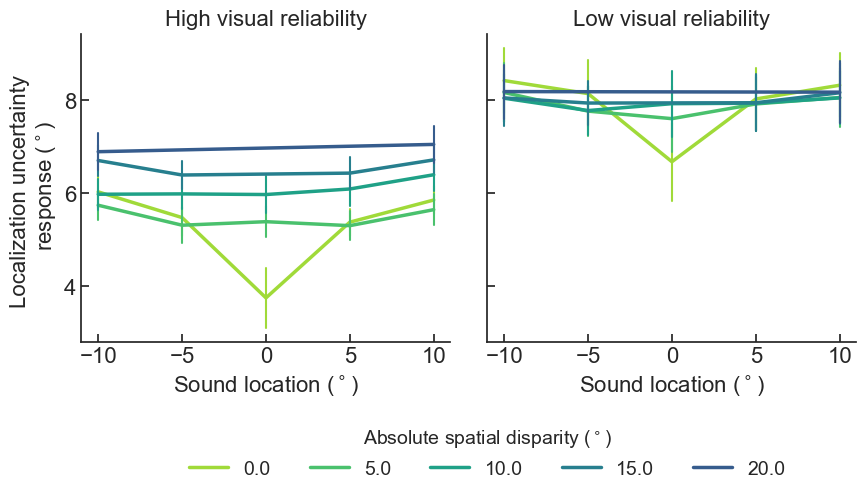

In [6]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 4), sharey=True, gridspec_kw={'wspace': 0.1})
plot_CI_size_by_condition(df=df_beh, axs=axs) 
axs[0].set_title('High visual reliability', fontsize=fontsize)
axs[1].set_title('Low visual reliability', fontsize=fontsize)
#fig.supxlabel('Auditory Stimulus location ($^\\circ$)', fontsize=fontsize,y=-0.05)
plt.savefig(os.path.join(plot_path, 'conf_inter', 'Allsub_ci_by_causal_disp_and_audloc.png'), bbox_inches='tight', dpi=300)

### the variability of confidence for congruent trials

In [63]:
df_plot = df_beh[(df_beh['Modality'] == 'A')&(df_beh.Sources==1)&(df_beh.AudLoc==df_beh.VisLoc)] #congruent common trials
summary = df_plot.groupby(['sub_id', 'VisRelLabel', 'AudLoc']).agg(ci_mean=('CISize', 'mean'), loc_std = ('RespLoc', 'std'), loc_mean = ('RespLoc', 'mean'),ci_std = ('CISize', 'std'), n=('RespLoc', 'size')).reset_index()
summary
#On subject-level, congruent common trials, plot the localization std against the mean uncertainty.  For each subject and each visual reliability, one location. , 

,sub_id,VisRelLabel,AudLoc,ci_mean,loc_std,loc_mean,ci_std,n
0,2,High,-10.0,5.187353,0.838787,-8.266176,1.646037,34
1,2,High,-5.0,4.175926,0.627923,-4.612222,0.901065,27
2,2,High,0.0,2.965294,0.510003,-0.079412,1.923725,34
3,2,High,5.0,4.877097,0.834609,4.839355,0.994723,31
4,2,High,10.0,5.123714,0.962913,8.224286,1.455117,35
...,...,...,...,...,...,...,...,...
75,25,Low,-10.0,12.180263,0.967807,-7.362368,2.225469,38
76,25,Low,-5.0,9.425000,1.079271,-4.824687,1.820030,32
77,25,Low,0.0,4.525714,2.051413,0.205429,4.183558,35
78,25,Low,5.0,10.222162,0.936040,5.622703,1.475830,37


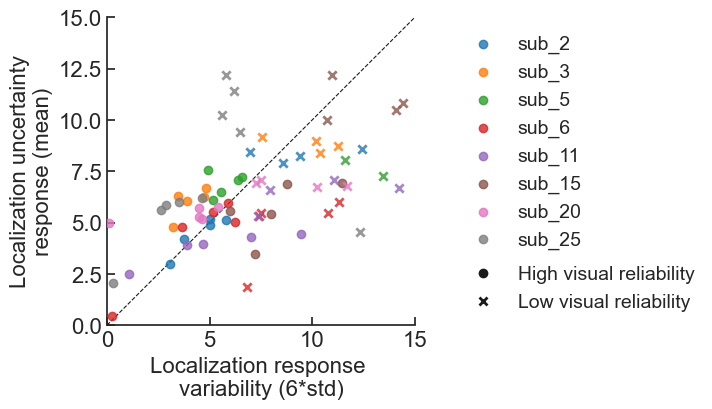

In [119]:
palette = sns.color_palette("tab10", n_colors=len(sub_lst))
color_map = dict(zip(sub_lst, palette))

fig, ax = plt.subplots(figsize=(10, 4))

for sub_id in sub_lst:
    data = summary[summary["sub_id"] == sub_id].copy()
    data['loc_std'] = data['loc_std'] * 6 # to make it a square

    ax.scatter(
        data.loc[data.VisRelLabel=='High', "loc_std"],
        data.loc[data.VisRelLabel=='High', "ci_mean"],
        #s=data.loc[data.VisRelLabel=='High', "n"],
        color=color_map[sub_id],
        alpha=0.8,
        marker='o',
        zorder=3,
        label=f"sub_{sub_id}"
    )
    ax.scatter(
        data.loc[data.VisRelLabel=='Low', "loc_std"],
        data.loc[data.VisRelLabel=='Low', "ci_mean"],
        #s=data.loc[data.VisRelLabel=='Low', "n"],
        alpha=0.8,
        marker='x',
        color=color_map[sub_id],
        linewidth=2,
        zorder=4,
        #label=f"sub_{sub_id}"
    )

ax.set_xlabel("Localization response \nvariability (6*std)", fontsize=fontsize)
ax.set_ylabel(
    "Localization uncertainty\nresponse (mean)",
    fontsize=fontsize
)

ax.plot([0, 15], [0, 15], "--k", lw=0.8)
ax.set_aspect("equal", adjustable="box")
ax.set_xlim([0, 15])
ax.set_ylim([0, 15])
clean_axs(ax)

# Subject legend (colors)
leg1 = ax.legend(
    bbox_to_anchor=(1.1, 1),
    loc="upper left",
    frameon=False,
    fontsize=fontsize-2,
)

# Reliability legend (markers)
reliability_handles = [
    Line2D(
        [0], [0],
        marker='o',
        color='k',
        linestyle='None',
        markersize=6,
        label='High visual reliability'
    ),
    Line2D(
        [0], [0],
        marker='x',
        color='k',
        linestyle='None',
        markersize=6,
        markeredgewidth=2,
        label='Low visual reliability'
    )
]

leg2 = ax.legend(
    handles=reliability_handles,
    bbox_to_anchor=(1.1, 0.25),
    loc="upper left",
    frameon=False,
    fontsize=fontsize-2,
    #title="Visual reliability"
)

# keep both legends
ax.add_artist(leg1)

plt.savefig(os.path.join(plot_path, 'ci_mean_loc_var_rel.png'), bbox_inches='tight', dpi=300)
plt.show()

## Causal confidence

In [ ]:
def plot_casual_conf(df,ax, palette=palette_beh, trial_type=None, leg=False):
    """
    Plot Confidence interval size/ causal confidence level / spatial report bias as a function of spatial disparities for different causal reports

    Parameters
    ----------
    df : pd.DataFrame
        processed data frame with CMB bias and lables.
    yvar : str
        the variable for examination. CISize/ConfLevel/bias.
    com_label : str
        Common/Separate/Total.
    trial_type : str
        'A' - auditory trials, 'V' - visual trials. Default None, which means both trial types are included.
    save_fig : bolen, optional
       The default is 0.
    Returns
    -------
    None.

    """
    trial_type_map = {'A':1, 'V':0}# 1 for auditory, 0 - for visual.
    if trial_type is not None:
        df = df[df.blockType==trial_type_map[trial_type]]

    #dfBySub = df.groupby(['sub_id', 'delta_VA', 'VisRelLabel'])['ConfLevel'].mean().reset_index()
    # helper fuction
    def plot_condition(df_cond, color,label):
         # Mean, SEM and total number of trials - two steps averaging
        summary_sub = (
            df_cond
            .groupby(["delta_VA", "sub_id"])
            .agg(
                mean=('ConfLevel', "mean"),
                #sem=(resp_var, "sem"),
                n=('ConfLevel', "size")
            )
            .reset_index()
            #.sort_values("AudLoc")
        )
        summary = (
            summary_sub
            .groupby(["delta_VA"])
            .agg(
                mean=('mean', "mean"),
                sem=('mean', "sem"),
                n=('n', "sum")
            )
            .reset_index()
            .sort_values("delta_VA")
        )

        ax.errorbar(
            summary["delta_VA"],
            summary["mean"],
            yerr=summary["sem"],
            color=color,
            linewidth=2,
            capsize=0,
            label=label,
            zorder=2,
            #alpha=0.7,
            marker='o',
            markersize=5,
        )
        ax.scatter(
                summary["delta_VA"],
                summary["mean"],
                s=summary["n"], 
                color=color,
                # edgecolors="black",
                # linewidth=0.5,
                zorder=3,
                alpha=0.7,
            )
    plot_condition(
        df.loc[df.VisRelLabel == 'High'],
        color=palette['High'],
        label="High visual reliability"
    )
    plot_condition(
        df.loc[df.VisRelLabel == 'Low'],
        color=palette['Low'],
        label="Low visual reliability"
    )

    clean_axs(ax, fontsize=fontsize-2)  
    ax.set_xlabel('Spatial disparity, V - A ($^\circ$)', fontsize = fontsize)
    #ax.set_ylabel('Causal confidence (0-100)', fontsize = fontsize)
    ax.xaxis.set_major_locator(MultipleLocator(5))
    if leg:
        ax.legend(
                frameon=False, 
                ncol = 2, 
                loc = 'upper right', 
                bbox_to_anchor=(0.8, -0.2), 
                fontsize = fontsize-2)


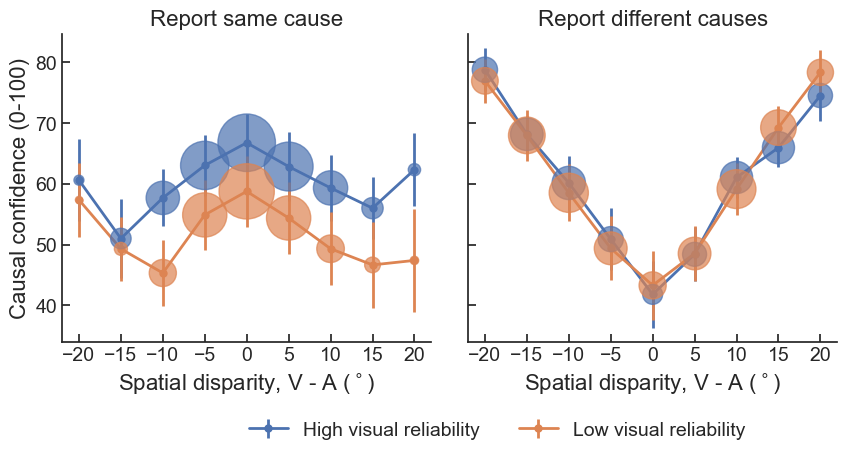

In [60]:
fig, axs = plt.subplots(figsize=(10, 4), ncols=2, nrows=1, sharey=True,
                        gridspec_kw={'wspace': 0.1}
                        )
plot_casual_conf(df=df_beh.loc[df_beh.Sources==1],ax=axs[0], palette=palette_beh, 
                 #trial_type='A', 
                 leg=False)
plot_casual_conf(df=df_beh.loc[df_beh.Sources==2],ax=axs[1], palette=palette_beh, 
                 #trial_type='A', 
                 leg=True)

axs[0].set_title('Report same cause', fontsize=fontsize, y=1)
axs[1].set_title('Report different causes', fontsize=fontsize, y=1)
axs
axs[0].set_ylabel('Causal confidence (0-100)', fontsize=fontsize)
fig.savefig(os.path.join(plot_path, "causal_conf_beh.png"), dpi=300, bbox_inches="tight")

### the relationship between perceptual and causal confidence

In [ ]:
from scipy.stats import zscore
df_plot = df_beh[(df_beh['Modality'] == 'A')].copy()
#df_plot = df_beh[(df_beh['Modality'] == 'A')&(df_beh.Sources==1)&(df_beh.AudLoc==df_beh.VisLoc)] #congruent common trials

# Standardize data relative to each subject's individual mean/std
df_plot['CISize_z'] = df_plot.groupby('sub_id')['CISize'].transform(zscore)
df_plot['ConfLevel_z'] = df_plot.groupby('sub_id')['ConfLevel'].transform(zscore)

summary = df_plot.groupby(['sub_id', 'VisRelLabel', 'delta_VA', 'Sources']).agg(
    ci_mean=('CISize', 'mean'), 
    cc_std = ('ConfLevel', 'std'), 
    cc_mean = ('ConfLevel', 'mean'),
    ci_std = ('CISize', 'std'), 
    n=('RespLoc', 'size'),
    ci_cv=('CISize', lambda x: x.std() / x.mean() if x.mean() != 0 else np.nan),
    cc_cv=('ConfLevel', lambda x: x.std() / x.mean() if x.mean() != 0 else np.nan),
    ci_zscore = ('CISize_z', 'mean'),
    cc_zscore = ('ConfLevel_z', 'mean')).reset_index()
#summary['Sources']=1
#On subject-level, congruent common trials, plot the localization std against the mean uncertainty.  For each subject and each visual reliability, one location. , 

In [ ]:
summary

,sub_id,VisRelLabel,AudLoc,ci_mean,cc_std,cc_mean,ci_std,n,Sources
0,2,High,-10.0,5.187353,22.626491,66.735294,1.646037,34,1
1,2,High,-5.0,4.175926,21.415573,54.370370,0.901065,27,1
2,2,High,0.0,2.965294,21.487799,76.176471,1.923725,34,1
3,2,High,5.0,4.877097,22.035894,56.225806,0.994723,31,1
4,2,High,10.0,5.123714,29.557862,56.742857,1.455117,35,1
...,...,...,...,...,...,...,...,...,...
75,25,Low,-10.0,12.180263,18.540870,84.578947,2.225469,38,1
76,25,Low,-5.0,9.425000,33.187092,70.187500,1.820030,32,1
77,25,Low,0.0,4.525714,36.468981,63.314286,4.183558,35,1
78,25,Low,5.0,10.222162,23.201008,82.135135,1.475830,37,1


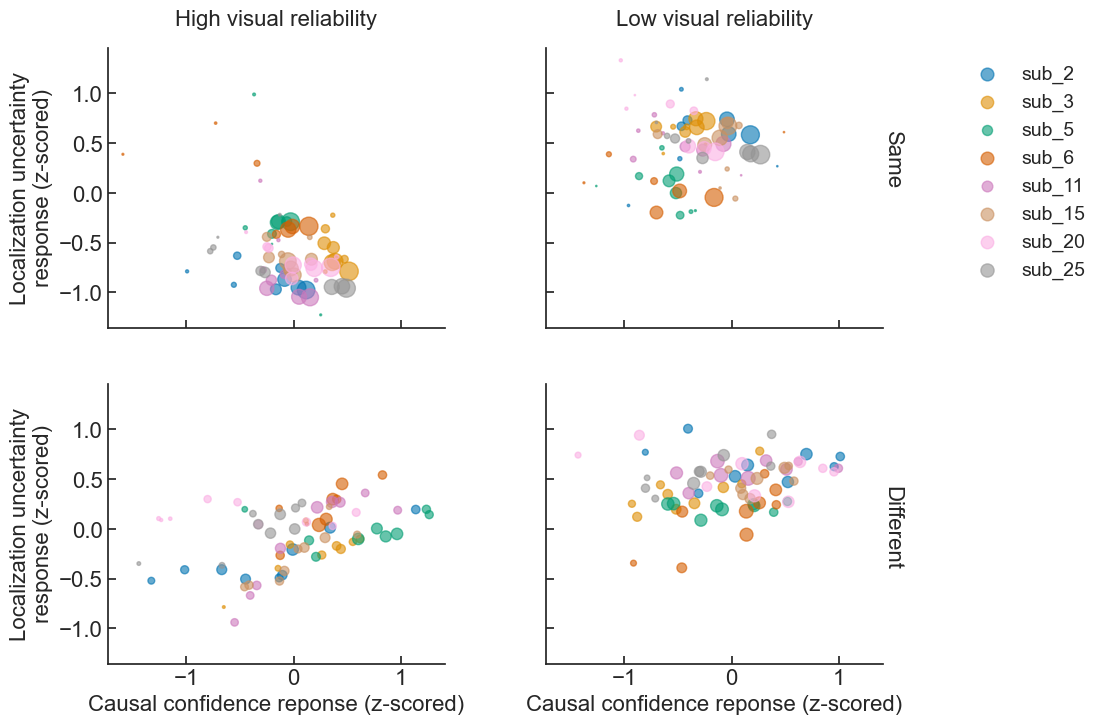

In [ ]:
fig, axs = plt.subplots(
    nrows=2, ncols=2,
    sharey=True,
    sharex=True,
    figsize=(10, 8),
    gridspec_kw={'hspace':0.2, 'wspace':0.3}
)

xvar, xlabel = 'cc_zscore', 'Causal confidence reponse (z-scored)'
y_var, ylabel = 'ci_zscore', 'Localization uncertainty\nresponse (z-scored)'
# Generate color palette mapping
palette = sns.color_palette("colorblind", n_colors=len(sub_lst))
color_map = dict(zip(sub_lst, palette))

# 2. Plotting loop
for sub_id in sub_lst:
    sub_data = summary[summary["sub_id"] == sub_id]

    for col, vis_rel in enumerate(["High", "Low"]):
        for row, sour in enumerate([1, 2]):
            data = sub_data[(sub_data["VisRelLabel"] == vis_rel) & (sub_data["Sources"] == sour)]

            axs[row, col].scatter(
                data[xvar],
                data[y_var],
                s=data["n"],
                color=color_map[sub_id],
                alpha=0.6,
                zorder=3,
                label=f"sub_{sub_id}"
            )

# 3. Corrected Formatting Loops (Explicitly iterating through rows and columns)
titles = ["High visual reliability", "Low visual reliability"]
y_labels = ["Same", "Different"] # Adjust labels if needed

for row in range(2):
    for col in range(2):
        # Apply your cleaning function safely to every axis
        clean_axs(axs[row, col]) 
        
        # Set X-labels only for the bottom row to prevent overlaps
        if row == 1:
            axs[row, col].set_xlabel(xlabel, fontsize=fontsize)
            
        # Set Titles only for the top row
        if row == 0:
            axs[row, col].set_title(titles[col], fontsize=fontsize, y=1.05)

# Set Y-labels cleanly on the leftmost subplots
for ax in axs[:,0]:
    ax.set_ylabel(ylabel,
            fontsize=fontsize)
# axs[0, 0].set_ylabel(f"{y_labels[0]}\nLocalization uncertainty (mean)", fontsize=fontsize)
# axs[1, 0].set_ylabel(f"{y_labels[1]}\nLocalization uncertainty (mean)", fontsize=fontsize)

# 4. Global legend handled outside the plot boundary
axs[0, 1].legend(
    title="",
    bbox_to_anchor=(1.2, 1),
    loc="upper left",
    frameon=False,
    fontsize=fontsize-2
)

fig.text(
        0.9, 0.74, 'Same',
        va='center', ha='left',
        fontsize=fontsize, rotation=270
    )

fig.text(
    0.9, 0.28, 'Different',
    va='center', ha='left',
    fontsize=fontsize, rotation=270
)
# Use bbox_inches="tight" during save to prevent cutting off the legend
fig.savefig(os.path.join(plot_path, "cc_ci_relation.png"), dpi=300, bbox_inches="tight")
plt.show()


In [10]:
df = df_beh.loc[(df_beh.Modality == 'A')&(df_beh.AudLoc== df_beh.VisLoc)] # congruent auditory-visual trials
df_plot = (
    df.groupby(['sub_id', 'VisRelLabel', 'AudLoc'])
      .agg(
          CI_mean=('CISize', 'mean'),
          CI_sd=('CISize', 'std'),
          bias_mean=('bias', 'mean'),
          bias_sd=('bias', 'std')
      )
      .reset_index()
)
df_plot

,sub_id,VisRelLabel,AudLoc,CI_mean,CI_sd,bias_mean,bias_sd
0,2,High,-10.0,5.224324,1.668122,-3.600723e-16,1.111541
1,2,High,-5.0,4.509722,1.147383,8.016517e-02,0.809399
2,2,High,0.0,3.015143,1.918031,-2.033822e-01,0.539386
3,2,High,5.0,4.978108,0.984995,-2.017905e-16,1.105083
4,2,High,10.0,5.127568,1.425662,2.760555e-16,0.966139
...,...,...,...,...,...,...,...
75,25,Low,-10.0,12.110256,2.239088,8.782149e-16,0.963280
76,25,Low,-5.0,9.598333,1.994457,-5.561988e-01,1.308240
77,25,Low,0.0,5.042821,4.259963,0.000000e+00,2.140606
78,25,Low,5.0,10.143421,1.534540,1.463968e-01,1.067052


## UNI - SENSORY

In [3]:
raw_data_path = 'P:/3026008.02/rawData/'
data_path = 'P:/3026008.02/AllData/'
sub_lst = [2, 3, 5, 6 ,11 ,15 ,20, 25]

#data preparation
df_uni_A = pd.DataFrame()
df_uni_V = pd.DataFrame()
for sub_id in sub_lst:
    subA_data = pd.read_excel(os.path.join(raw_data_path, 'Subj_' + str(sub_id) + '_BimodalAuditoryData_Excel.xlsx'))
    subV_data = pd.read_excel(os.path.join(raw_data_path, 'Subj_' + str(sub_id) + '_BimodalVisualData_Excel.xlsx'))
    # filter out the unisensory data
    sub_uniA_data = subA_data[subA_data['Vis Loc'].isna()].reset_index(drop=True)
    sub_uniA_data['sub_id'] = sub_id
    sub_uniA_data['Modality'] = 'A'
    sub_uniA_data['stim_loc'] = sub_uniA_data['Aud Loc']
    sub_uniA_data['Vis Rel'] = 0 # reassign the visual reliability to 0 for uni-sensory auditory blocks
    sub_uniV_data = subV_data[subV_data['Aud Loc'].isna()].reset_index(drop=True)
    sub_uniV_data['sub_id'] = sub_id
    sub_uniV_data['Modality'] = 'V'
    sub_uniV_data['stim_loc'] = sub_uniV_data['Vis Loc']
     # concatenate the data
    df_uni_V = pd.concat([df_uni_V, sub_uniV_data], ignore_index=True)
    df_uni_A = pd.concat([df_uni_A, sub_uniA_data], ignore_index=True)

In [4]:
df_uni_A = df_uni_A.rename(columns={'CI Size':'CISize', 'Aud Loc':'AudLoc', 'Vis Rel':'VisRel', 'Resp Loc':'RespLoc'})
df_uni_A.head()

,Block Nr,Trial Nr,AudLoc,Vis Loc,VisRel,RespLoc,CISize,Sources,Conf Level,sub_id,Modality,stim_loc
0,1,1,-5,NaN,0,-3.59,6.49,NaN,NaN,2,A,-5
1,1,13,0,NaN,0,-4.15,5.15,NaN,NaN,2,A,0
2,1,25,10,NaN,0,8.59,5.71,NaN,NaN,2,A,10
3,1,27,5,NaN,0,5.60,5.34,NaN,NaN,2,A,5
4,1,28,-10,NaN,0,-4.93,5.80,NaN,NaN,2,A,-10


In [5]:
df_stat = df_uni_A.groupby(['sub_id', 'VisRel', 'AudLoc'])['RespLoc'].agg(['mean', 'std']).reset_index()
df_aud = df_uni_A.merge(df_stat.loc[:, ['sub_id', 'VisRel', 'AudLoc', 'mean']], how='left', on=['sub_id', 'VisRel', 'AudLoc'])
df_aud['bias'] = df_aud['RespLoc'] - df_aud['mean']
df_aud['bias_cc'] = df_aud['RespLoc'] - df_aud['AudLoc']
df_aud.head()

,Block Nr,Trial Nr,AudLoc,Vis Loc,VisRel,RespLoc,CISize,Sources,Conf Level,sub_id,Modality,stim_loc,mean,bias,bias_cc
0,1,1,-5,NaN,0,-3.59,6.49,NaN,NaN,2,A,-5,-3.978108,0.388108,1.41
1,1,13,0,NaN,0,-4.15,5.15,NaN,NaN,2,A,0,0.212329,-4.362329,-4.15
2,1,25,10,NaN,0,8.59,5.71,NaN,NaN,2,A,10,8.218784,0.371216,-1.41
3,1,27,5,NaN,0,5.60,5.34,NaN,NaN,2,A,5,4.385270,1.214730,0.60
4,1,28,-10,NaN,0,-4.93,5.80,NaN,NaN,2,A,-10,-7.594730,2.664730,5.07


In [6]:
df_plot = pd.concat([df_aud.loc[: ,['sub_id', 'AudLoc', 'VisRel', 'CISize', 'bias', 'bias_cc']],df_beh.loc[(df_beh.Modality == 'A') &(df_beh.abs_delta_VA==0), ['sub_id','AudLoc', 'VisRel', 'CISize', 'bias','bias_cc']]], ignore_index=True)
df_plot

,sub_id,AudLoc,VisRel,CISize,bias,bias_cc
0,2,-5.0,0.0,6.49,0.388108,1.41
1,2,0.0,0.0,5.15,-4.362329,-4.15
2,2,10.0,0.0,5.71,0.371216,-1.41
3,2,5.0,0.0,5.34,1.214730,0.60
4,2,-10.0,0.0,5.80,2.664730,5.07
...,...,...,...,...,...,...
5778,25,10.0,2.0,9.22,0.808462,-1.63
5779,25,10.0,2.0,8.40,-0.511538,-2.95
5780,25,10.0,2.0,12.33,0.038462,-2.40
5781,25,10.0,2.0,8.47,2.778462,0.34


In [7]:
df_plot['vislabel']= df_plot.VisRel.map({0:'Uni-sensory', 1:'Bi-sensory congruent high V reliability', 2:'Bi-sensory congruent low V reliability'})

In [24]:
df_plot

,sub_id,AudLoc,VisRel,CISize,bias,vislabel
0,2,-5.0,0.0,6.49,0.388108,Uni-sensory
1,2,0.0,0.0,5.15,-4.362329,Uni-sensory
2,2,10.0,0.0,5.71,0.371216,Uni-sensory
3,2,5.0,0.0,5.34,1.214730,Uni-sensory
4,2,-10.0,0.0,5.80,2.664730,Uni-sensory
...,...,...,...,...,...,...
5778,25,10.0,2.0,9.22,0.808462,Bi-sensory congruent low V reliability
5779,25,10.0,2.0,8.40,-0.511538,Bi-sensory congruent low V reliability
5780,25,10.0,2.0,12.33,0.038462,Bi-sensory congruent low V reliability
5781,25,10.0,2.0,8.47,2.778462,Bi-sensory congruent low V reliability


Text(0.5, 0, 'Auditory location ($^\\circ$)')

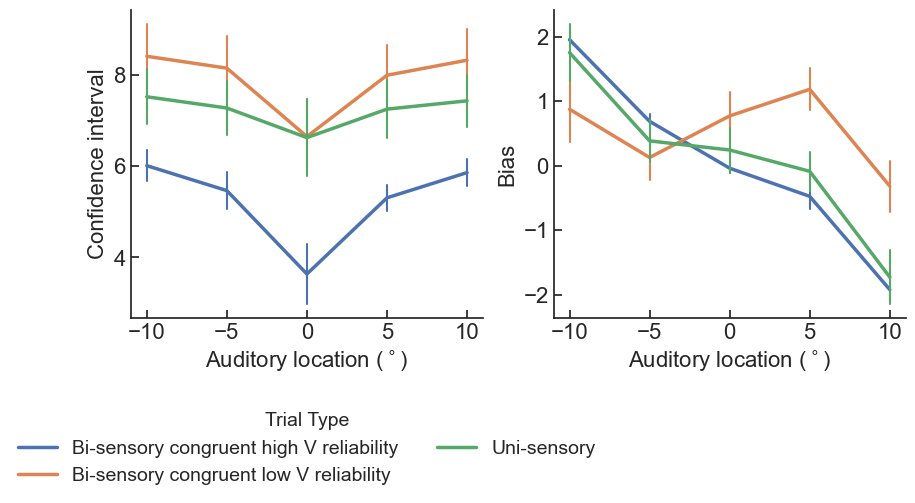

In [14]:
from matplotlib.gridspec import GridSpec


palette = sns.color_palette("viridis", as_cmap=False)

df_plot = df_plot.groupby(['sub_id', 'vislabel', 'AudLoc'])[['CISize','bias', 'bias_cc']].mean().reset_index()

fig = plt.figure(figsize=(10, 4))
gs = GridSpec(1, 2, figure=fig)

ax1 = fig.add_subplot(gs[:, 0])
sns.lineplot(
    data=df_plot,
    x='AudLoc',
    y='CISize',
    hue = 'vislabel',
    #palette=palette,
    linewidth=2.5,
    estimator = 'mean',
    errorbar='se',
    err_style='bars',
    ax=ax1
)
ax2 = fig.add_subplot(gs[0, 1])
sns.lineplot(
    data=df_plot,
    x='AudLoc',
    y='bias_cc',
    hue = 'vislabel',
    #palette=palette,
    linewidth=2.5,
    estimator = 'mean',
    errorbar='se',
    err_style='bars',
    ax=ax2,
    legend = None
)

#sns.lineplot(x=np.linspace(-10, 10, 100), y=np.linspace(-10, 10, 100), linestyle="--", color = 'red', ax = axs[1])

clean_axs(ax1)
clean_axs(ax2)

ax1.legend(
    title='Trial Type',
    frameon=False,
    loc='lower center',
    ncol=2,
    bbox_to_anchor=(0.5, -0.6),
    fontsize=fontsize-2,
    title_fontsize=fontsize-2
)
#axs.set_title('Uni-sensory auditory report', fontsize=fontsize)
#axs[1].set_ylim(-0.5,0.5)
ax1.set_ylabel('Confidence interval', fontsize=fontsize)
ax1.set_xlabel('Auditory location ($^\\circ$)', fontsize=fontsize)
ax2.set_ylabel('Bias', fontsize=fontsize)
ax2.set_xlabel('Auditory location ($^\\circ$)', fontsize=fontsize)

In [29]:
df_plot

,sub_id,vislabel,AudLoc,CISize,bias
0,2,Bi-sensory congruent high V reliability,-10.0,5.224324,-3.600723e-16
1,2,Bi-sensory congruent high V reliability,-5.0,4.509722,8.016517e-02
2,2,Bi-sensory congruent high V reliability,0.0,3.015143,-2.033822e-01
3,2,Bi-sensory congruent high V reliability,5.0,4.978108,-2.017905e-16
4,2,Bi-sensory congruent high V reliability,10.0,5.127568,2.760555e-16
...,...,...,...,...,...
115,25,Uni-sensory,-10.0,9.966800,-1.302662e-16
116,25,Uni-sensory,-5.0,9.059452,-2.433366e-16
117,25,Uni-sensory,0.0,7.911867,-7.105427e-17
118,25,Uni-sensory,5.0,9.697838,2.160434e-16


In [19]:
from scipy import stats
t_stat, p_value = stats.ttest_1samp(df_plot.bias[(df_plot.vislabel=='Bi-sensory congruent low V reliability')&(df_plot.AudLoc==-5)], popmean=0, alternative="less")

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: -2.362774143792926
p-value: 0.025068130454723125
